## ⚙️ **Libraries Import**

In [374]:
# Import necessary libraries
import os

# Import necessary modules
import logging
import random
import numpy as np
import optuna

# Import PyTorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Metal) backend!")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU.")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mute warnings
import warnings
warnings.filterwarnings("ignore")

Using MPS (Apple Metal) backend!
PyTorch version: 2.8.0
Device: mps


## ⏳ **Data Loading**

In [375]:
kaggle_dir = "/kaggle/input/the-pirate-pain-dataset"
local_dir = "./data"
dir = local_dir if device.type == "mps" else kaggle_dir
os.environ["DATASET_train"] = dir+"/pirate_pain_train.csv"
os.environ["DATASET_test"] = dir+"/pirate_pain_test.csv"
os.environ["DATASET_train-labels"] = dir+"/pirate_pain_train_labels.csv"

## 🔎 **Train-test split**

In [376]:
# Load the dataset from a CSV file
df_train = pd.read_csv(os.environ["DATASET_train"])
df_public_test = pd.read_csv(os.environ["DATASET_test"])
df_labels = pd.read_csv(os.environ["DATASET_train-labels"])

## 🔄 **Data Preprocessing**

### Mapping

In [377]:
# Map string to int
mapping = {
    "one+peg_leg": 1,
    "one+hook_hand": 1,
    "one+eye_patch": 1,
    "two": 2,
}

# Map labels
label_mapping = {label: idx for idx, label in enumerate(df_labels['label'].unique())}
df_labels['label_idx'] = df_labels['label'].map(label_mapping)
df_labels.drop('label', axis=1, inplace=True)
df_labels.head()

# for df in [df_train, df_val, df_public_test]:
for df in [df_train, df_public_test]:
    # Mapp all data types to float32
    for col in df:
        if df[col].dtype == 'int64' and col not in ['sample_index', 'time']:
            df[col] = df[col].astype(np.float32)
        elif df[col].dtype == 'float64':
            df[col] = df[col].astype(np.float32)
        elif df[col].dtype == 'object':
            df[col] = df[col].replace(mapping)
            df[col] = df[col].astype(np.float32)

    # # Create pirate indicator from static features
    # df['pirate'] = df[['n_legs', 'n_hands', 'n_eyes']].apply(
    #     lambda row: 0 if (row == 2).all() else 1, axis=1
    # )
    # df.drop(['n_legs', 'n_hands', 'n_eyes'], axis=1, inplace=True)

    # # Drop joint_30, uninformative feature
    # df.drop('joint_30', axis=1, inplace=True)

    # # Add time sine and cosine features
    # if 'time' in df.columns:
    #     df["time_sin"] = np.sin(2 * np.pi * df["time"] / 80)
    #     df["time_cos"] = np.cos(2 * np.pi * df["time"] / 80)

for df in [df_train, df_public_test]:
    print(df.describe)

<bound method NDFrame.describe of         sample_index  time  pain_survey_1  pain_survey_2  pain_survey_3  \
0                  0     0            2.0            0.0            2.0   
1                  0     1            2.0            2.0            2.0   
2                  0     2            2.0            0.0            2.0   
3                  0     3            2.0            2.0            2.0   
4                  0     4            2.0            2.0            2.0   
...              ...   ...            ...            ...            ...   
105755           660   155            2.0            2.0            0.0   
105756           660   156            2.0            2.0            0.0   
105757           660   157            0.0            2.0            2.0   
105758           660   158            2.0            2.0            2.0   
105759           660   159            2.0            2.0            2.0   

        pain_survey_4  n_legs  n_hands  n_eyes  joint_00  ...    

### Feature selection

In [378]:
# exclude = ["sample_index", 'pirate']

# temporal_feature_cols = [col for col in df_train.columns if col not in exclude]
# static_feature_cols = ['pirate']

### Scaling

In [379]:
# from sklearn.preprocessing import MinMaxScaler

# # Initialize scaler
# scaler = MinMaxScaler()

# # Fit scaler only on training data
# scaler.fit(df_train[temporal_feature_cols])

# # Transform train, val, public_test
# for df in [df_train, df_public_test]:
#     df[temporal_feature_cols] = scaler.transform(df[temporal_feature_cols])


In [380]:
# Display preprocessed data
df_train.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,1.990923,1.990923,1.990923,0.943095,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.094841,0.094841,0.094841,0.202051,...,4.974496e-03,5.472244e-03,1.235449e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.828277,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.005126,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746148e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.081039,...,2.800090e-06,3.079464e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.407968,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [ ]:
# Generate a single image with selected joints (0, 4, 8, 12, 16, 20, 24, 28, 30) showing mean and std for each pain class across 160 timesteps
print("Generating single image with selected joints (joint_00, joint_04, joint_08, joint_12, joint_16, joint_20, joint_24, joint_28, joint_30)...")

# Merge train data with labels to get pain classes
df_train_labeled = df_train.merge(df_labels, on='sample_index', how='left')

# Verify time column exists and check its range
if 'time' not in df_train_labeled.columns:
    raise ValueError("'time' column not found in dataframe!")
print(f"Time range: {df_train_labeled['time'].min()} to {df_train_labeled['time'].max()}")
print(f"Number of unique time steps: {df_train_labeled['time'].nunique()}")

# Get joints with indices 0, 4, 8, 12, 16, 20, 24, 28, and 30 - 9 joints total
joint_indices = list(range(0, 29, 4)) + [30]  # [0, 4, 8, 12, 16, 20, 24, 28, 30]
joint_cols = [f'joint_{i:02d}' for i in joint_indices]

# Get pain class names from label mapping
inverse_label_mapping = {v: k for k, v in label_mapping.items()}
pain_classes = [inverse_label_mapping[i] for i in sorted(inverse_label_mapping.keys())]

# Create a single figure with subplots: 3 rows x 3 columns = 9 subplots (perfect fit for 9 joints)
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

# Colors for each pain class
colors = ['blue', 'orange', 'red']

# Import for custom legend handles
from matplotlib.lines import Line2D

# Process each joint
for idx, joint_col in enumerate(joint_cols):
    if joint_col not in df_train_labeled.columns:
        print(f"Skipping {joint_col} - not found in dataframe")
        axes[idx].axis('off')
        continue
    
    ax = axes[idx]
    
    # Group by pain class and time, calculate mean and std
    grouped = df_train_labeled.groupby(['label_idx', 'time'])[joint_col].agg(['mean', 'std']).reset_index()
    
    # Debug: Print info for first joint
    if idx == 0:
        print(f"\nDebug info for {joint_col}:")
        print(f"  Grouped data shape: {grouped.shape}")
        print(f"  Time range in grouped data: {grouped['time'].min()} to {grouped['time'].max()}")
        print(f"  Sample of grouped data (first 5 rows):")
        print(grouped.head())
    
    # Plot for each pain class
    for class_idx, pain_class in enumerate(pain_classes):
        class_data = grouped[grouped['label_idx'] == class_idx].copy()
        
        # Sort by time to ensure proper ordering
        class_data = class_data.sort_values('time')
        
        times = class_data['time'].values
        means = class_data['mean'].values
        stds = class_data['std'].values
        
        # Fill NaN std values with 0 (for cases where there's only one sample)
        stds = np.nan_to_num(stds, nan=0.0)
        
        # Ensure we have data to plot
        if len(times) > 0:
            # Plot mean line
            ax.plot(times, means, label=f'{pain_class}', color=colors[class_idx], linewidth=1.5)
            
            # Fill area for mean ± std
            ax.fill_between(times, means - stds, means + stds, 
                            alpha=0.2, color=colors[class_idx])
    
    # Set labels and title for each subplot with larger fonts
    ax.set_title(f'{joint_col}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Explicitly set x-axis limits and ticks
    ax.set_xlim(0, 159)
    ax.set_xticks([0, 40, 80, 120, 159])
    ax.tick_params(labelsize=12)
    
# No empty subplots to hide (3×3 = 9 exactly)

# Create a single legend for the entire figure showing which color corresponds to which pain class
legend_handles = []
legend_labels = []
for class_idx, pain_class in enumerate(pain_classes):
    handle = Line2D([0], [0], color=colors[class_idx], linewidth=2, label=pain_class)
    legend_handles.append(handle)
    legend_labels.append(pain_class)

# Add overall title with larger font
# fig.suptitle('Mean and Std by Pain Class Across 160 Timesteps', 
#              fontsize=28, fontweight='bold', y=0.995)

# Adjust layout to prevent overlap, leaving space for legend at the top
# Adjust layout to prevent overlap, leaving more space for very large legend at the top
plt.tight_layout(rect=[0, 0, 1, 0.82])

# Add the legend to the figure (at the top) with very large font
fig.legend(handles=legend_handles, labels=legend_labels, loc='upper center', fontsize=50, framealpha=0.9, bbox_to_anchor=(0.5, 0.96), ncol=3)

# Save the single figure
output_path = "all_joints_mean_std_by_class.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"\nSingle image with 9 selected joints (joint_00, joint_04, joint_08, joint_12, joint_16, joint_20, joint_24, joint_28, joint_30) saved to: {output_path}")


Generating single image with selected joints (joint_00, joint_04, joint_08, joint_12, joint_16, joint_20, joint_24, joint_28, joint_30)...
Time range: 0 to 159
Number of unique time steps: 160


## 🛠️ **Model Building**

In [ ]:
class CSHN_ConvBlock(nn.Module):
    """ Implements the CSHN Core: Conv1D -> BatchNorm1D -> SiLU. """
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super(CSHN_ConvBlock, self).__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.act = nn.SiLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class CSHN_FeatureExtractor(nn.Module):
    """ 3-layer CNN feature extractor with tunable filter sizes. """
    def __init__(self, num_raw_features, c1_filters, c2_filters, c3_filters, cnn_dropout_rate):
        super(CSHN_FeatureExtractor, self).__init__()
        
        # Fixed Kernel/Padding based on CSHN architecture
        C1_KERNEL, C2_KERNEL, C3_KERNEL = 8, 5, 3 
        C2_PADDING, C3_PADDING = 2, 1
        
        # C1 (Input features -> C1_FILTERS)
        self.c1 = CSHN_ConvBlock(num_raw_features, c1_filters, C1_KERNEL, padding=0)
        # C2 (C1_FILTERS -> C2_FILTERS)
        self.c2 = CSHN_ConvBlock(c1_filters, c2_filters, C2_KERNEL, padding=C2_PADDING)  
        # C3 (C2_FILTERS -> C3_FILTERS)
        self.c3 = CSHN_ConvBlock(c2_filters, c3_filters, C3_KERNEL, padding=C3_PADDING)
        
        self.dropout = nn.Dropout(cnn_dropout_rate)

    def forward(self, x):
        # x enters as (Batch, Time, Features) -> Permute to (Batch, Features, Time) for Conv1D
        x = x.transpose(1, 2)
        
        x = self.c1(x) 
        x = self.c2(x) 
        x = self.c3(x) 
        
        # Permute back for the RNN input: (Batch, Features, Time) -> (Batch, Time, Features)
        x = x.transpose(1, 2)
        
        x = self.dropout(x)
        return x

class RecurrentClassifierWithStaticBranch(nn.Module):
    """
    Recurrent classifier that augments the temporal representation with
    a rule-based indicator derived from static features.
    Uses CSHN feature extractor (3-layer CNN) before the RNN.

    Optionally applies a learnable attention pooling layer over the RNN outputs
    to focus on the most discriminative timesteps instead of relying solely on
    the last hidden state.
    """
    def __init__(
            self,
            temporal_input_size,
            static_input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='LSTM',
            bidirectional=False,
            dropout_rate=0.2,
            c1_filters=64,
            c2_filters=128,
            c3_filters=256,
            cnn_dropout=0.1,
            attention_dim=128,
            use_attention=True
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.use_attention = use_attention

        # CSHN Feature Extractor: 3-layer CNN with SiLU activation
        self.cnn = CSHN_FeatureExtractor(
            num_raw_features=temporal_input_size,
            c1_filters=c1_filters,
            c2_filters=c2_filters,
            c3_filters=c3_filters,
            cnn_dropout_rate=cnn_dropout
        )
        
        # Output size from CSHN is c3_filters
        conv_output_size = c3_filters

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }
        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")
        rnn_module = rnn_map[rnn_type]

        # Dropout for RNN (only between layers if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Recurrent layer for temporal features (now receives conv output)
        self.rnn = rnn_module(
            input_size=conv_output_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            rnn_output_size = hidden_size * 2
        else:
            rnn_output_size = hidden_size

        if self.use_attention:
            self.attention_net = nn.Sequential(
                nn.Linear(rnn_output_size, attention_dim),
                nn.Tanh(),
                nn.Linear(attention_dim, 1)
            )
        else:
            self.attention_net = None

        # Linear head over temporal features and a separate weight for the indicator
        self.classifier = nn.Linear(rnn_output_size, num_classes)
        self.pirate_effect = nn.Linear(1, num_classes, bias=False)

    def _apply_attention(self, rnn_out):
        # rnn_out: (batch, seq_len, feature_dim)
        att_scores = self.attention_net(rnn_out).squeeze(-1)  # (batch, seq_len)
        att_weights = torch.softmax(att_scores, dim=1)
        context = torch.bmm(att_weights.unsqueeze(1), rnn_out).squeeze(1)
        return context

    def forward(self, x_temporal, x_static):
        """
        x_temporal: (batch_size, seq_length, temporal_input_size)
        x_static: (batch_size, static_input_size)
        """
        # Apply CSHN feature extractor (handles transpose internally)
        # Input: (batch, seq_len, features) -> Output: (batch, seq_len, c3_filters)
        x_cnn = self.cnn(x_temporal)
        
        # Process temporal features through RNN
        rnn_out, hidden = self.rnn(x_cnn)

        if self.use_attention:
            temporal_features = self._apply_attention(rnn_out)
        else:
            # Extract last hidden state
            if self.rnn_type == 'LSTM':
                hidden = hidden[0]

            if self.bidirectional:
                hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
                temporal_features = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
            else:
                temporal_features = hidden[-1]  # (batch_size, hidden_size)

        # Rule-based static indicator: 1 if x_static equals 1, else 0
        pirate_indicator = (x_static == 1.0).float()

        # Get logits (temporal contribution + rule-based adjustment)
        logits = self.classifier(temporal_features) + self.pirate_effect(pirate_indicator)
        return logits


In [ ]:
def build_sequence(df, window, stride, temporal_cols, static_cols, df_labels=None):
    """
    Build sliding window sequences with static features separated.
    Can be used for both training (with labels) and test (without labels).
    
    Parameters
    ----------
    df : DataFrame
        Feature data (contains sample_index, time, and feature columns)
    window : int
        Number of timesteps per sequence
    stride : int
        Step between windows (controls overlap)
    temporal_cols : list
        List of temporal feature column names (e.g., joint features)
    static_cols : list
        List of static feature column names (e.g., n_legs, n_hands, n_eyes)
    df_labels : DataFrame, optional
        Label data (sample_index, label_idx). If None, returns sample_indices instead of labels.
    
    Returns
    -------
    X_temporal : np.array   shape = (num_sequences, window, num_temporal_features)
    X_static : np.array     shape = (num_sequences, num_static_features)
    y_or_indices : np.array shape = (num_sequences,) - labels if df_labels provided, else sample_indices
    """
    
    X_temporal = []
    X_static = []
    y_or_indices = []
    
    for sid in df["sample_index"].unique():
        # Extract temporal features per sequence
        temp_temporal = df[df["sample_index"] == sid][temporal_cols].values.astype("float32")
        
        # Check and handle NaN values in temporal features
        if np.isnan(temp_temporal).any():
            # Forward fill, then backward fill, then fill remaining with 0
            temp_df = pd.DataFrame(temp_temporal, columns=temporal_cols)
            temp_df = temp_df.ffill().bfill().fillna(0)
            temp_temporal = temp_df.values.astype("float32")
        
        # Extract static features (same for all timesteps, take first row)
        temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
        
        # Check and handle NaN values in static features
        if np.isnan(temp_static).any():
            temp_static = np.nan_to_num(temp_static, nan=0.0)
        
        # Get label if df_labels is provided, otherwise we'll use sample_index
        if df_labels is not None:
            label = df_labels.loc[df_labels["sample_index"] == sid, "label_idx"].iloc[0]
        
        # Padding section
        remainder = len(temp_temporal) % window
        if remainder > 0:
            pad_len = window - remainder
            padding = np.zeros((pad_len, temp_temporal.shape[1]), dtype="float32")
            temp_temporal = np.concatenate((temp_temporal, padding), axis=0)
        
        # Build sliding windows
        idx = 0
        while idx + window <= len(temp_temporal):
            X_temporal.append(temp_temporal[idx:idx + window])
            X_static.append(temp_static)  # Static features are the same for all windows from same sample
            if df_labels is not None:
                y_or_indices.append(label)
            else:
                y_or_indices.append(sid)
            idx += stride
    
    return np.array(X_temporal), np.array(X_static), np.array(y_or_indices)


In [ ]:
class TemporalStaticDataset(torch.utils.data.Dataset):
    """
    Custom Dataset that handles both temporal and static features.
    """
    def __init__(self, X_temporal, X_static, y):
        """
        Args:
            X_temporal: np.array of shape (num_samples, seq_len, num_temporal_features)
            X_static: np.array of shape (num_samples, num_static_features)
            y: np.array of shape (num_samples,)
        """
        self.X_temporal = torch.from_numpy(X_temporal).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long()
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_temporal[idx], self.X_static[idx], self.y[idx]


In [ ]:
def train_one_epoch_with_static(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Modified training function to handle models with static features.
    """
    model.train()
    
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for batch_idx, (inputs_temporal, inputs_static, targets) in enumerate(train_loader):
        inputs_temporal = inputs_temporal.to(device)
        inputs_static = inputs_static.to(device)
        targets = targets.to(device)
        
        # Check for NaN in inputs
        if torch.isnan(inputs_temporal).any() or torch.isnan(inputs_static).any():
            print(f"Warning: NaN in inputs at batch {batch_idx}, skipping")
            continue
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            # Forward pass with both temporal and static features
            logits = model(inputs_temporal, inputs_static)
            
            # Check for NaN in logits
            if torch.isnan(logits).any():
                print(f"Warning: NaN in logits at batch {batch_idx}")
                continue
            
            loss = criterion(logits, targets)
            
            # Check for NaN in loss
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Warning: Invalid loss at batch {batch_idx}: {loss.item()}")
                continue
            
            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm
            
            # Check again after regularization
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Warning: Invalid loss after regularization at batch {batch_idx}")
                continue
        
        scaler.scale(loss).backward()
        
        # Gradient clipping to prevent explosion
        if device.type == 'cuda':
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            # For CPU/MPS, clip gradients before optimizer step
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        
        running_loss += loss.item() * inputs_temporal.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Calculate F1 score with error handling
    all_targets_arr = np.concatenate(all_targets)
    all_predictions_arr = np.concatenate(all_predictions)
    
    # Check for NaN or invalid values
    if np.isnan(epoch_loss) or np.isinf(epoch_loss):
        print(f"Warning: Invalid loss value: {epoch_loss}")
        epoch_f1 = 0.0
    else:
        try:
            epoch_f1 = f1_score(all_targets_arr, all_predictions_arr, average='weighted', zero_division=0)
            if np.isnan(epoch_f1):
                epoch_f1 = 0.0
        except:
            epoch_f1 = 0.0
    
    return epoch_loss, epoch_f1


def validate_one_epoch_with_static(model, val_loader, criterion, device):
    """
    Modified validation function to handle models with static features.
    """
    model.eval()
    
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs_temporal, inputs_static, targets in val_loader:
            inputs_temporal = inputs_temporal.to(device)
            inputs_static = inputs_static.to(device)
            targets = targets.to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs_temporal, inputs_static)
                loss = criterion(logits, targets)
            
            running_loss += loss.item() * inputs_temporal.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader.dataset)
    
    # Calculate F1 score with error handling
    all_targets_arr = np.concatenate(all_targets)
    all_predictions_arr = np.concatenate(all_predictions)
    
    # Check for NaN or invalid values
    if np.isnan(epoch_loss) or np.isinf(epoch_loss):
        print(f"Warning: Invalid loss value: {epoch_loss}")
        epoch_accuracy = 0.0
    else:
        try:
            epoch_accuracy = f1_score(all_targets_arr, all_predictions_arr, average='weighted', zero_division=0)
            if np.isnan(epoch_accuracy):
                epoch_accuracy = 0.0
        except:
            epoch_accuracy = 0.0
    
    return epoch_loss, epoch_accuracy


In [ ]:
import torch.nn.functional as F
class OrdinalWeightedLoss(nn.Module):
    def __init__(self, weight=None, lambda_val=1.0, label_smoothing=0.1):
        super().__init__()
        self.register_buffer('class_indices', torch.arange(3, dtype=torch.float32))  # optional default
        self.weight = weight
        self.lambda_val = lambda_val
        self.label_smoothing = label_smoothing

    def forward(self, logits, true_labels):
        # Cross-entropy (use provided class weights if any)
        cce_loss = F.cross_entropy(logits, true_labels, weight=self.weight)

        probs = F.softmax(logits, dim=1)

        # ensure class indices match current number of classes and device/dtype
        num_classes = logits.size(1)
        if self.class_indices.numel() != num_classes or self.class_indices.device != logits.device:
            class_indices = torch.arange(num_classes, device=logits.device, dtype=logits.dtype)
        else:
            class_indices = self.class_indices.to(logits.device).to(logits.dtype)

        true_labels_float = true_labels.float().unsqueeze(1)  # (B,1)
        distance_matrix = true_labels_float - class_indices     # (B, C)

        # squared distance weighted by predicted probability, then mean over batch
        penalty = (distance_matrix.pow(2) * probs).sum(dim=1)
        penalty_loss = penalty.mean()

        return cce_loss + self.lambda_val * penalty_loss

In [ ]:
import threading

# Thread lock for orthogonal initialization to prevent CUDA lazy wrapper issues
_orthogonal_init_lock = threading.Lock()

def initialize_weights(model: nn.Module, init_scheme: str):
    """
    Initializes weights, correctly skipping 1D tensors (like biases) 
    that cause 'Fan in and fan out' errors.
    Thread-safe for parallel execution.
    """
    for name, param in model.named_parameters():
        # Skip parameters with fewer than 2 dimensions (typically biases and BatchNorm params)
        if param.dim() < 2:
            # Optionally initialize biases to zero, or skip them
            if 'bias' in name:
                torch.nn.init.constant_(param.data, 0.0)
            continue

        # Apply initialization schemes only to weight matrices (dim >= 2)
        if init_scheme == 'xavier_uniform':
            torch.nn.init.xavier_uniform_(param.data)
        elif init_scheme == 'kaiming_normal':
            # Good for ReLU/Leaky ReLU (common in surrounding layers)
            torch.nn.init.kaiming_normal_(param.data, mode='fan_in', nonlinearity='leaky_relu')
        elif init_scheme == 'orthogonal':
            # Use lock to prevent CUDA lazy wrapper issues in parallel execution
            with _orthogonal_init_lock:
                torch.nn.init.orthogonal_(param.data)


In [ ]:
def fit_with_static(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
                    l1_lambda=0, l2_lambda=0, patience=10, verbose=1, scheduler=None, trial=None, 
                    experiment_name="best_model", weight_max_norm=None, fold_idx=None, n_folds=None):
    """
    Train model with static features, supporting Optuna trials for hyperparameter optimization.
    
    Args:
        trial: Optuna trial object for pruning (optional)
        experiment_name: Name for saving model checkpoints
        weight_max_norm: Maximum L2 norm for weight constraints (optional)
        fold_idx: Fold index for unique step calculation in parallel execution (optional)
        n_folds: Number of folds for unique step calculation (optional)
    """
    
    os.makedirs("models", exist_ok=True)
    checkpoint_path = f"models/{experiment_name}.pt"
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1, patience_cnt = 0, 0
    best_epoch = 0

    def unwrap_model(m):
        return m.module if hasattr(m, "module") else m
    
    # Weight constraint function
    def apply_weight_constraint(model_to_clip, max_norm):
        with torch.no_grad():
            for name, module in model_to_clip.named_modules():
                if isinstance(module, (nn.Linear, nn.Conv1d, nn.Conv2d)):
                    if hasattr(module, 'weight') and module.weight is not None:
                        norm = module.weight.norm(2)
                        if norm > max_norm:
                            module.weight.data.mul_(max_norm / norm)
    
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch_with_static(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )
        
        # Apply weight constraints if specified
        if weight_max_norm is not None and weight_max_norm > 0:
            apply_weight_constraint(unwrap_model(model), weight_max_norm)
        
        val_loss, val_f1 = validate_one_epoch_with_static(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        # Update learning rate scheduler if provided
        if scheduler is not None:
            scheduler.step(val_f1)
        
        # Optuna pruning
        if trial is not None:
            try:
                # Check if trial should be pruned BEFORE reporting (avoids race conditions)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
                
                # Calculate unique step for parallel execution: step = epoch * n_folds + fold_idx
                # For sequential execution or when fold info not provided, use epoch as step
                if fold_idx is not None and n_folds is not None:
                    step = epoch * n_folds + fold_idx
                else:
                    step = epoch
                
                # Only report if trial hasn't finished (handles race condition where another fold pruned)
                try:
                    trial.report(val_f1, step)
                except (RuntimeError, ValueError) as e:
                    # Handle "trial already finished" or step already reported gracefully
                    if "already finished" in str(e) or "already reported" in str(e):
                        # Trial was finished by another fold or step was reported, stop this fold
                        raise optuna.exceptions.TrialPruned()
                    else:
                        raise
            except optuna.exceptions.TrialPruned:
                raise
            except Exception as e:
                # Only print unexpected errors, silently skip if trial is finished
                if "already finished" not in str(e) and "already reported" not in str(e):
                    print(f"Error during Optuna report: {e}")
                # If trial is finished, treat as pruned
                try:
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()
                except:
                    raise optuna.exceptions.TrialPruned()
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(unwrap_model(model).state_dict(), checkpoint_path)
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose > 0:
                    print(f"Early stopping at epoch {epoch}")
                break
        
        if verbose > 0 and epoch % verbose == 0:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")
            print(f"Epoch {epoch}: Train F1={train_f1:.4f}, Val F1={val_f1:.4f}")
            if scheduler is not None:
                print(f"Epoch {epoch}: LR={optimizer.param_groups[0]['lr']:.6f}")
    
    # Restore best model weights
    if best_epoch > 0:
        state_dict = torch.load(checkpoint_path, map_location='cpu')
        unwrap_model(model).load_state_dict(state_dict)
        if verbose > 0:
            print(f"Best model restored from epoch {best_epoch} with Val F1={best_f1:.4f}")
    
    return model, history, best_f1

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
unique_labels = np.sort(df_labels['label_idx'].unique())
weights_array = compute_class_weight(class_weight="balanced", classes=unique_labels, y=df_labels["label_idx"])
weights_tensor_cpu = torch.tensor(weights_array, dtype=torch.float32)
weights_tensor = weights_tensor_cpu.to(device)

## 🔍 **Optuna Hyperparameter Optimization**


In [ ]:
from sklearn.model_selection import GroupKFold
from concurrent.futures import ThreadPoolExecutor

# Optuna configuration
BATCH_SIZE_OPTUNA = 32
EPOCHS_OPTUNA = 200
PATIENCE_OPTUNA = 15
N_SPLITS = 4

use_parallel_folds = device.type == "cuda" and torch.cuda.device_count() >= 2
max_parallel_gpus = min(2, torch.cuda.device_count()) if use_parallel_folds else 0
parallel_device_ids = list(range(max_parallel_gpus)) if use_parallel_folds else []

def set_seed(seed_value):
    """Set random seeds for reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
    elif torch.backends.mps.is_available():
        # MPS doesn't have manual_seed_all, but we can set the seed
        pass

# Prepare data for Optuna (use df_train which already has train/val split) 
# Actually no, we removed train/validation split cause we're doing k fold
df_train_for_cv = df_train.copy()
df_train_for_cv = df_train_for_cv.merge(df_labels, on='sample_index', how='left')

# OOF placeholders
num_classes = 3
oof_preds_train = np.zeros(len(df_train_for_cv))
oof_probs_train = np.zeros((len(df_train_for_cv), num_classes))

# GroupKFold split
gkf = GroupKFold(n_splits=N_SPLITS)

def run_fold_training(fold, trial_number, df_train_k, df_val_k, params, device_or_id, trial=None):
    """Train a single fold on the specified device and return validation outputs.
    
    Args:
        device_or_id: Either a torch.device (for sequential) or int (CUDA device_id for parallel)
        trial: Optuna trial object for pruning (None for parallel execution)
    """
    if isinstance(device_or_id, int):
        # Parallel CUDA case
        device_id = device_or_id
        torch.cuda.set_device(device_id)
        local_device = torch.device(f"cuda:{device_id}")
        print(f"Training Fold {fold+1} on cuda:{device_id}...")
    else:
        # Sequential case (any device type)
        local_device = device_or_id
        print(f"Training Fold {fold+1} on {local_device}...")

    window = params["window"]
    stride = params["stride"]

    X_train_temporal, X_train_static, y_train = build_sequence(
        df_train_k, window, stride, temporal_feature_cols, static_feature_cols, df_labels
    )
    X_val_temporal, X_val_static, y_val = build_sequence(
        df_val_k, window, stride, temporal_feature_cols, static_feature_cols, df_labels
    )

    X_train_temporal = X_train_temporal.astype(np.float32)
    X_train_static = X_train_static.astype(np.float32)
    y_train = y_train.astype(np.int64)

    X_val_temporal = X_val_temporal.astype(np.float32)
    X_val_static = X_val_static.astype(np.float32)
    y_val = y_val.astype(np.int64)

    train_ds = TemporalStaticDataset(X_train_temporal, X_train_static, y_train)
    val_ds = TemporalStaticDataset(X_val_temporal, X_val_static, y_val)
    pin_memory = local_device.type == "cuda"
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE_OPTUNA,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        pin_memory=pin_memory
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE_OPTUNA,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=pin_memory
    )

    model = RecurrentClassifierWithStaticBranch(
        temporal_input_size=X_train_temporal.shape[2],
        static_input_size=X_train_static.shape[1],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        num_classes=num_classes,
        rnn_type=params["rnn_type"],
        bidirectional=params["bidirectional"],
        dropout_rate=params["rnn_dropout"],
        c1_filters=params["c1_filters"],
        c2_filters=params["c2_filters"],
        c3_filters=params["c3_filters"],
        cnn_dropout=params["cnn_dropout"]
    ).to(local_device)

    param_count = sum(p.numel() for p in model.parameters())
    if param_count > 50000:
        # Discard trial if parameter count is too high
        if trial is not None:
            raise optuna.exceptions.TrialPruned(f"Parameter count {param_count} exceeds limit of 200000")
        else:
            # If no trial object (shouldn't happen), still raise to stop execution
            raise ValueError(f"Parameter count {param_count} exceeds limit of 200000")
    
    if local_device.type == "cuda" and (not hasattr(local_device, "index") or local_device.index == 0):
        print(f"Model parameter count: {param_count}")

    initialize_weights(model, init_scheme=params["init_scheme"])

    weights_local = params["weights"].to(local_device)
    if params["use_ordinal_loss"]:
        criterion = OrdinalWeightedLoss(weight=weights_local, lambda_val=params["ordinal_lambda"]).to(local_device)
    else:
        criterion = nn.CrossEntropyLoss(weight=weights_local).to(local_device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.1, patience=10, min_lr=1e-7
    )
    scaler_amp = torch.amp.GradScaler(enabled=True)

    model, _, best_val_f1 = fit_with_static(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS_OPTUNA,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler_amp,
        device=local_device,
        l1_lambda=params["l1_lambda"],
        l2_lambda=0,
        patience=PATIENCE_OPTUNA,
        verbose=5,
        scheduler=scheduler,
        trial=trial,
        experiment_name=f"optuna_trial_{trial_number}_fold_{fold}",
        weight_max_norm=params["weight_max_norm"],
        fold_idx=fold,
        n_folds=N_SPLITS
    )

    _, _, val_sample_ids = build_sequence(
        df_val_k, window, stride, temporal_feature_cols, static_feature_cols, df_labels=None
    )
    val_sample_ids = np.array(val_sample_ids)

    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb_temporal, xb_static, _ in val_loader:
            xb_temporal = xb_temporal.to(local_device)
            xb_static = xb_static.to(local_device)
            out = model(xb_temporal, xb_static)
            probs_list.append(out.softmax(dim=1).cpu().numpy())

    probs_fold = np.concatenate(probs_list, axis=0) if probs_list else np.empty((0, num_classes))
    min_len = min(len(probs_fold), len(val_sample_ids))
    if min_len > 0:
        probs_fold = probs_fold[:min_len]
        val_sample_ids = val_sample_ids[:min_len]
    else:
        probs_fold = np.empty((0, num_classes))
        val_sample_ids = np.array([])

    if local_device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "fold": fold,
        "best_val_f1": best_val_f1,
        "probs_fold": probs_fold,
        "val_sample_ids": val_sample_ids,
    }

def objective(trial):
    """Optuna objective function for hyperparameter optimization with static features."""
    fold_scores = []

    # Trial-level hyperparameters
    seed_hp = trial.suggest_int("SEED", 0, 10000)
    set_seed(seed_hp)

    # Window and stride hyperparameters
    window_hp = trial.suggest_categorical("WINDOW", [20, 32, 40, 80])
    stride_hp = trial.suggest_categorical("STRIDE", [5, 10, 15, 20, 25])
    if stride_hp >= window_hp:
        raise optuna.exceptions.TrialPruned()

    # CNN hyperparameters
    c1_filters_hp = trial.suggest_categorical("c1_filters", [4, 8, 16])
    c2_filters_hp = trial.suggest_categorical("c2_filters", [8, 16, 32, 48, 64])
    if (c1_filters_hp == 16 and c2_filters_hp not in [32, 48]) or (c1_filters_hp == 32 and c2_filters_hp not in [64, 96]):
        raise optuna.exceptions.TrialPruned()
    c3_filters_hp = trial.suggest_categorical("c3_filters", [16, 32, 64, 96, 128])
    if c3_filters_hp not in [c2_filters_hp * 2, c2_filters_hp * 3]:
        raise optuna.exceptions.TrialPruned()
    cnn_dropout_hp = trial.suggest_float("cnn_dropout", 0.1, 0.5)

    # RNN hyperparameters
    hidden_size_hp = trial.suggest_categorical("hidden_size", [8, 16, 32, 64])
    num_layers_hp = trial.suggest_int("num_layers", 1, 3)
    rnn_dropout_hp = trial.suggest_float("rnn_dropout", 0.2, 0.7)
    rnn_type_hp = trial.suggest_categorical("rnn_type", ["LSTM", "GRU"])
    bidirectional_hp = trial.suggest_categorical("bidirectional", [True, False])

    # Training hyperparameters
    init_scheme_hp = trial.suggest_categorical("init_scheme", ["xavier_uniform", "orthogonal"])
    lr_hp = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay_hp = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    l1_lambda_hp = trial.suggest_float("l1_lambda", 1e-7, 1e-4, log=True)
    weight_max_norm_hp = trial.suggest_float("weight_max_norm", 0.1, 6.0)

    # Loss function choice (optional - can tune ordinal loss lambda)
    use_ordinal_loss = trial.suggest_categorical("use_ordinal_loss", [True, False])
    ordinal_lambda = trial.suggest_float("ordinal_lambda", 0.5, 2.0) if use_ordinal_loss else 1.0

    # Print all trial hyperparameters
    print(f"{'='*80}")
    print(f"Trial {trial.number}: Starting {N_SPLITS}-fold cross-validation")
    all_hparams = {
        "SEED": seed_hp,
        "WINDOW": window_hp,
        "STRIDE": stride_hp,
        "c1_filters": c1_filters_hp,
        "c2_filters": c2_filters_hp,
        "c3_filters": c3_filters_hp,
        "cnn_dropout": cnn_dropout_hp,
        "hidden_size": hidden_size_hp,
        "num_layers": num_layers_hp,
        "rnn_dropout": rnn_dropout_hp,
        "rnn_type": rnn_type_hp,
        "bidirectional": bidirectional_hp,
        "init_scheme": init_scheme_hp,
        "lr": lr_hp,
        "weight_decay": weight_decay_hp,
        "l1_lambda": l1_lambda_hp,
        "weight_max_norm": weight_max_norm_hp,
        "use_ordinal_loss": use_ordinal_loss,
        "ordinal_lambda": ordinal_lambda,
    }
    for k, v in all_hparams.items():
        print(f"{k:>16}: {v}")
    print(f"{'='*80}")

    fold_results = []

    if use_parallel_folds:
        with ThreadPoolExecutor(max_workers=max_parallel_gpus) as executor:
            futures = []
            for fold, (train_idx, val_idx) in enumerate(
                gkf.split(df_train_for_cv, df_train_for_cv["label_idx"], groups=df_train_for_cv["sample_index"])
            ):
                df_train_k = df_train_for_cv.iloc[train_idx].reset_index(drop=True)
                df_val_k = df_train_for_cv.iloc[val_idx].reset_index(drop=True)
                fold_params = {
                    "window": window_hp,
                    "stride": stride_hp,
                    "c1_filters": c1_filters_hp,
                    "c2_filters": c2_filters_hp,
                    "c3_filters": c3_filters_hp,
                    "cnn_dropout": cnn_dropout_hp,
                    "hidden_size": hidden_size_hp,
                    "num_layers": num_layers_hp,
                    "rnn_dropout": rnn_dropout_hp,
                    "rnn_type": rnn_type_hp,
                    "bidirectional": bidirectional_hp,
                    "init_scheme": init_scheme_hp,
                    "lr": lr_hp,
                    "weight_decay": weight_decay_hp,
                    "l1_lambda": l1_lambda_hp,
                    "weight_max_norm": weight_max_norm_hp,
                    "use_ordinal_loss": use_ordinal_loss,
                    "ordinal_lambda": ordinal_lambda,
                    "weights": weights_tensor_cpu.clone()
                }
                device_id = parallel_device_ids[fold % max_parallel_gpus]
                print(f"--- Trial {trial.number}, Fold {fold+1}/{N_SPLITS} --- [cuda:{device_id}]")
                futures.append(
                    executor.submit(
                        run_fold_training,
                        fold,
                        trial.number,
                        df_train_k,
                        df_val_k,
                        fold_params,
                        device_id,
                        trial  # Enable pruning even in parallel execution
                    )
                )
            for future in futures:
                try:
                    fold_results.append(future.result())
                except optuna.exceptions.TrialPruned as e:
                    # If any fold triggers pruning, propagate it
                    print(f"Trial {trial.number} pruned during parallel fold execution")
                    raise

        fold_results.sort(key=lambda x: x["fold"])
        for result in fold_results:
            fold_idx = result["fold"]
            best_val_f1 = result["best_val_f1"]
            probs_fold = result["probs_fold"]
            val_sample_ids = result["val_sample_ids"]

            if len(probs_fold) > 0 and len(val_sample_ids) > 0:
                probs_fold_df = pd.DataFrame(probs_fold, columns=[0, 1, 2])
                probs_fold_df['sample_index'] = val_sample_ids
                probs_fold_avg = probs_fold_df.groupby('sample_index')[[0, 1, 2]].mean()

                for sample_id, probs_row in probs_fold_avg.iterrows():
                    mask = df_train_for_cv['sample_index'] == sample_id
                    if mask.any():
                        idx = df_train_for_cv[mask].index[0]
                        oof_probs_train[idx] = probs_row.values
                        oof_preds_train[idx] = probs_row.values.argmax()

            fold_scores.append(best_val_f1)
            print(f"Fold {fold_idx+1} completed - Best Val F1: {best_val_f1:.4f}")

    else:
        # Sequential execution - use same function but with global device
        for fold, (train_idx, val_idx) in enumerate(
            gkf.split(df_train_for_cv, df_train_for_cv["label_idx"], groups=df_train_for_cv["sample_index"])
        ):
            print(f"\n--- Trial {trial.number}, Fold {fold+1}/{N_SPLITS} ---")

            df_train_k = df_train_for_cv.iloc[train_idx].reset_index(drop=True)
            df_val_k = df_train_for_cv.iloc[val_idx].reset_index(drop=True)

            fold_params = {
                "window": window_hp,
                "stride": stride_hp,
                "c1_filters": c1_filters_hp,
                "c2_filters": c2_filters_hp,
                "c3_filters": c3_filters_hp,
                "cnn_dropout": cnn_dropout_hp,
                "hidden_size": hidden_size_hp,
                "num_layers": num_layers_hp,
                "rnn_dropout": rnn_dropout_hp,
                "rnn_type": rnn_type_hp,
                "bidirectional": bidirectional_hp,
                "init_scheme": init_scheme_hp,
                "lr": lr_hp,
                "weight_decay": weight_decay_hp,
                "l1_lambda": l1_lambda_hp,
                "weight_max_norm": weight_max_norm_hp,
                "use_ordinal_loss": use_ordinal_loss,
                "ordinal_lambda": ordinal_lambda,
                "weights": weights_tensor_cpu.clone()
            }

            try:
                result = run_fold_training(
                    fold,
                    trial.number,
                    df_train_k,
                    df_val_k,
                    fold_params,
                    device,  # Pass global device
                    trial=trial  # Enable pruning for sequential execution
                )

                fold_idx = result["fold"]
                best_val_f1 = result["best_val_f1"]
                probs_fold = result["probs_fold"]
                val_sample_ids = result["val_sample_ids"]

                if len(probs_fold) > 0 and len(val_sample_ids) > 0:
                    probs_fold_df = pd.DataFrame(probs_fold, columns=[0, 1, 2])
                    probs_fold_df['sample_index'] = val_sample_ids
                    probs_fold_avg = probs_fold_df.groupby('sample_index')[[0, 1, 2]].mean()

                    for sample_id, probs_row in probs_fold_avg.iterrows():
                        mask = df_train_for_cv['sample_index'] == sample_id
                        if mask.any():
                            idx = df_train_for_cv[mask].index[0]
                            oof_probs_train[idx] = probs_row.values
                            oof_preds_train[idx] = probs_row.values.argmax()

                fold_scores.append(best_val_f1)
                print(f"Fold {fold_idx+1} completed - Best Val F1: {best_val_f1:.4f}")

            except optuna.exceptions.TrialPruned:
                print(f"Trial {trial.number} Fold {fold+1} was pruned")
                raise
            except Exception as e:
                print(f"Trial {trial.number} Fold {fold+1} failed: {e}")
                import traceback
                traceback.print_exc()
                return 0.0

    mean_score = np.mean(fold_scores) if fold_scores else 0.0
    print(f"Trial {trial.number} completed - Mean F1 across {N_SPLITS} folds: {mean_score:.4f}")
    print(f"{'='*80}")
    return mean_score

# Create and run Optuna study
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5, n_startup_trials=3)
)
study.optimize(objective, n_trials=300)

print("--- Optuna Tuning Complete ---")
print(f"Best trial: {study.best_trial.number}, Best mean F1 (training folds): {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-11-17 23:16:58,727] A new study created in memory with name: no-name-11afe547-f2cf-46e3-a2e0-ee05be4aba35
Traceback (most recent call last):
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 369, in objective
    result = run_fold_training(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 61, in run_fold_training
    X_train_temporal, X_train_static, y_train = build_sequence(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/3586192775.py", line 44, in build_sequence
    temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py", line 4119, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/indexes/base.py", line 6212, in _get_i

Trial 0: Starting 4-fold cross-validation
            SEED: 6039
          WINDOW: 80
          STRIDE: 15
      c1_filters: 8
      c2_filters: 16
      c3_filters: 32
     cnn_dropout: 0.14566480806023724
     hidden_size: 16
      num_layers: 1
     rnn_dropout: 0.4315984553655214
        rnn_type: GRU
   bidirectional: True
     init_scheme: xavier_uniform
              lr: 0.0009249536648466697
    weight_decay: 0.0003375577402886187
       l1_lambda: 3.839714867045393e-06
 weight_max_norm: 0.6135317945039898
use_ordinal_loss: True
  ordinal_lambda: 0.8694301809338876

--- Trial 0, Fold 1/4 ---
Training Fold 1 on mps...
Trial 0 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 5: Starting 4-fold cross-validation
            SEED: 5055
          WINDOW: 80
          STRIDE: 5
      c1_filters: 4
      c2_filters: 32
      c3_filters: 64
     cnn_dropout: 0.1940343820104521
     hidden_size: 16
      num_layers: 3
     rnn_dropout: 0.38586943171

Traceback (most recent call last):
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 369, in objective
    result = run_fold_training(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 61, in run_fold_training
    X_train_temporal, X_train_static, y_train = build_sequence(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/3586192775.py", line 44, in build_sequence
    temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py", line 4119, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/indexes/base.py", line 6212, in _get_indexer_strict
    self._raise_if_missing(keyarr, indexer, axis_name)
  File "/Users/andreamastroberti/Library/Pyth

Training Fold 1 on mps...
Trial 18 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 21: Starting 4-fold cross-validation
            SEED: 4579
          WINDOW: 80
          STRIDE: 5
      c1_filters: 8
      c2_filters: 32
      c3_filters: 64
     cnn_dropout: 0.11932650824819069
     hidden_size: 16
      num_layers: 1
     rnn_dropout: 0.3952561168534729
        rnn_type: LSTM
   bidirectional: True
     init_scheme: xavier_uniform
              lr: 3.1887824185325715e-05
    weight_decay: 0.00021510716496690602
       l1_lambda: 3.203414008083103e-05
 weight_max_norm: 0.38370370476261884
use_ordinal_loss: True
  ordinal_lambda: 1.1001300508070504

--- Trial 21, Fold 1/4 ---
Training Fold 1 on mps...
Trial 21 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 22: Starting 4-fold cross-validation
            SEED: 4458
          WINDOW: 80
          STRIDE: 5
      c1_filters: 8
      c2_filters: 32
      

Traceback (most recent call last):
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 369, in objective
    result = run_fold_training(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 61, in run_fold_training
    X_train_temporal, X_train_static, y_train = build_sequence(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/3586192775.py", line 44, in build_sequence
    temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py", line 4119, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/indexes/base.py", line 6212, in _get_indexer_strict
    self._raise_if_missing(keyarr, indexer, axis_name)
  File "/Users/andreamastroberti/Library/Pyth

...

Trial 280: Starting 4-fold cross-validation
            SEED: 5872
          WINDOW: 80
          STRIDE: 5
      c1_filters: 8
      c2_filters: 32
      c3_filters: 96
     cnn_dropout: 0.28429887865816644
     hidden_size: 32
      num_layers: 3
     rnn_dropout: 0.41953636075471273
        rnn_type: GRU
   bidirectional: True
     init_scheme: xavier_uniform
              lr: 0.000666442144199156
    weight_decay: 0.00036308991601259036
       l1_lambda: 3.508897118098408e-05
 weight_max_norm: 1.466978498140468
use_ordinal_loss: True
  ordinal_lambda: 1.154328821261258

--- Trial 280, Fold 1/4 ---
Training Fold 1 on mps...
Trial 280 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 281: Starting 4-fold cross-validation
            SEED: 5278
          WINDOW: 80
          STRIDE: 10
      c1_filters: 4
      c2_filters: 32
      c3_filters: 64
     cnn_dropout: 0.1704908945738992
     hidden_size: 16
      num_layers: 1
     rnn_dropout: 0.3335

[I 2025-11-17 23:17:05,946] Trial 286 pruned. 
[I 2025-11-17 23:17:05,969] Trial 287 pruned. 
[I 2025-11-17 23:17:05,991] Trial 288 pruned. 
[I 2025-11-17 23:17:06,012] Trial 289 pruned. 
Traceback (most recent call last):
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 369, in objective
    result = run_fold_training(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 61, in run_fold_training
    X_train_temporal, X_train_static, y_train = build_sequence(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/3586192775.py", line 44, in build_sequence
    temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py", line 4119, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
  File "/Users/andreamastroberti/Library/Python/3.9/l

Trial 290: Starting 4-fold cross-validation
            SEED: 1918
          WINDOW: 80
          STRIDE: 10
      c1_filters: 8
      c2_filters: 32
      c3_filters: 96
     cnn_dropout: 0.21431456388552642
     hidden_size: 16
      num_layers: 2
     rnn_dropout: 0.4732895318169828
        rnn_type: GRU
   bidirectional: True
     init_scheme: xavier_uniform
              lr: 0.0009128480312291853
    weight_decay: 0.00026242200456739513
       l1_lambda: 2.6119224577128648e-05
 weight_max_norm: 0.5234626957439745
use_ordinal_loss: True
  ordinal_lambda: 1.4636326555388817

--- Trial 290, Fold 1/4 ---
Training Fold 1 on mps...
Trial 290 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 294: Starting 4-fold cross-validation
            SEED: 4884
          WINDOW: 80
          STRIDE: 5
      c1_filters: 16
      c2_filters: 32
      c3_filters: 96
     cnn_dropout: 0.11429467023685458
     hidden_size: 8
      num_layers: 3
     rnn_dropout: 0.

Traceback (most recent call last):
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 369, in objective
    result = run_fold_training(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/1241760481.py", line 61, in run_fold_training
    X_train_temporal, X_train_static, y_train = build_sequence(
  File "/var/folders/4n/lhpwlzq16rb325j9m5q2z2kr0000gn/T/ipykernel_31745/3586192775.py", line 44, in build_sequence
    temp_static = df[df["sample_index"] == sid][static_cols].values[0].astype("float32")
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py", line 4119, in __getitem__
    indexer = self.columns._get_indexer_strict(key, "columns")[1]
  File "/Users/andreamastroberti/Library/Python/3.9/lib/python/site-packages/pandas/core/indexes/base.py", line 6212, in _get_indexer_strict
    self._raise_if_missing(keyarr, indexer, axis_name)
  File "/Users/andreamastroberti/Library/Pyth

Trial 297: Starting 4-fold cross-validation
            SEED: 7829
          WINDOW: 20
          STRIDE: 15
      c1_filters: 8
      c2_filters: 32
      c3_filters: 64
     cnn_dropout: 0.1423764373657285
     hidden_size: 16
      num_layers: 1
     rnn_dropout: 0.40987235029275654
        rnn_type: GRU
   bidirectional: True
     init_scheme: xavier_uniform
              lr: 0.00022827241576546916
    weight_decay: 3.3889519252529893e-06
       l1_lambda: 2.2422134970438614e-07
 weight_max_norm: 2.950682682350464
use_ordinal_loss: True
  ordinal_lambda: 1.9961160109231193

--- Trial 297, Fold 1/4 ---
Training Fold 1 on mps...
Trial 297 Fold 1 failed: "None of [Index(['pirate'], dtype='object')] are in the [columns]"
Trial 298: Starting 4-fold cross-validation
            SEED: 2546
          WINDOW: 80
          STRIDE: 5
      c1_filters: 4
      c2_filters: 32
      c3_filters: 96
     cnn_dropout: 0.1315088656230564
     hidden_size: 64
      num_layers: 3
     rnn_dropout: 0.3

## 🎯 **Retrain Best Model and Store History**

In [ ]:
best_params = {
    "SEED": 4742,
    "WINDOW": 20,
    "STRIDE": 5,
    "c1_filters": 8,
    "c2_filters": 16,
    "c3_filters": 32,
    "cnn_dropout": 0.26285121544001006,
    "hidden_size": 8,
    "num_layers": 1,
    "rnn_dropout": 0.5942257868566418,
    "rnn_type": "LSTM",
    "bidirectional": False,
    "init_scheme": "orthogonal",
    "lr": 0.0003542063344908316,
    "weight_decay": 2.2322137386337777e-05,
    "l1_lambda": 1.071304385383899e-07,
    "weight_max_norm": 5.788518864488345,
    "use_ordinal_loss": False,
    "ordinal_lambda": 1.0
}

In [ ]:
# Retrain best model using k-fold cross-validation
print("--- Retraining Best Model with K-Fold Cross-Validation ---")
best_params = study.best_params if not best_params else best_params
set_seed(best_params["SEED"])
N_SPLITS = 10
PATIENCE_OPTUNA = 30

# Use best hyperparameters
window_best = best_params["WINDOW"]
stride_best = best_params["STRIDE"]
c1_filters_best = best_params["c1_filters"]
c2_filters_best = best_params["c2_filters"]
c3_filters_best = best_params["c3_filters"]
cnn_dropout_best = best_params["cnn_dropout"]
hidden_size_best = best_params["hidden_size"]
num_layers_best = best_params["num_layers"]
rnn_dropout_best = best_params["rnn_dropout"]
rnn_type_best = best_params["rnn_type"]
bidirectional_best = best_params["bidirectional"]
init_scheme_best = best_params["init_scheme"]
lr_best = best_params["lr"]
weight_decay_best = best_params["weight_decay"]
l1_lambda_best = best_params["l1_lambda"]
weight_max_norm_best = best_params["weight_max_norm"]
use_ordinal_loss_best = best_params.get("use_ordinal_loss", False)
ordinal_lambda_best = best_params.get("ordinal_lambda", 1.0)

# Prepare data for k-fold cross-validation (use full df_train)
df_train_for_cv = df_train.copy()
df_train_for_cv = df_train_for_cv.merge(df_labels, on='sample_index', how='left')

# K-fold cross-validation setup
gkf = GroupKFold(n_splits=N_SPLITS)
fold_histories = []
fold_scores = []
fold_models = []

print(f"Starting {N_SPLITS}-fold cross-validation with best hyperparameters...")
print(f"{'='*80}")

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_train_for_cv, df_train_for_cv["label_idx"], groups=df_train_for_cv["sample_index"])
):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    
    df_train_k = df_train_for_cv.iloc[train_idx].reset_index(drop=True)
    df_val_k = df_train_for_cv.iloc[val_idx].reset_index(drop=True)
    
    # Build sequences for this fold
    X_train_temporal_k, X_train_static_k, y_train_k = build_sequence(
        df_train_k, window_best, stride_best, temporal_feature_cols, static_feature_cols, df_labels
    )
    X_val_temporal_k, X_val_static_k, y_val_k = build_sequence(
        df_val_k, window_best, stride_best, temporal_feature_cols, static_feature_cols, df_labels
    )

    X_train_temporal_k = X_train_temporal_k.astype(np.float32)
    X_train_static_k = X_train_static_k.astype(np.float32)
    y_train_k = y_train_k.astype(np.int64)
    X_val_temporal_k = X_val_temporal_k.astype(np.float32)
    X_val_static_k = X_val_static_k.astype(np.float32)
    y_val_k = y_val_k.astype(np.int64)
    
    # Create datasets and loaders
    train_ds_k = TemporalStaticDataset(X_train_temporal_k, X_train_static_k, y_train_k)
    val_ds_k = TemporalStaticDataset(X_val_temporal_k, X_val_static_k, y_val_k)
    pin_memory = device.type == "cuda"
    train_loader_k = DataLoader(train_ds_k, batch_size=BATCH_SIZE_OPTUNA, shuffle=True, drop_last=False, num_workers=0, pin_memory=pin_memory)
    val_loader_k = DataLoader(val_ds_k, batch_size=BATCH_SIZE_OPTUNA, shuffle=False, drop_last=False, num_workers=0, pin_memory=pin_memory)
    
    # Create model for this fold
    fold_model = RecurrentClassifierWithStaticBranch(
        temporal_input_size=X_train_temporal_k.shape[2],
        static_input_size=X_train_static_k.shape[1],
        hidden_size=hidden_size_best,
        num_layers=num_layers_best,
        num_classes=3,
        rnn_type=rnn_type_best,
        bidirectional=bidirectional_best,
        dropout_rate=rnn_dropout_best,
        c1_filters=c1_filters_best,
        c2_filters=c2_filters_best,
        c3_filters=c3_filters_best,
        cnn_dropout=cnn_dropout_best
    ).to(device)
    
    initialize_weights(fold_model, init_scheme=init_scheme_best)
    
    # Loss function
    if use_ordinal_loss_best:
        criterion_k = OrdinalWeightedLoss(weight=weights_tensor, lambda_val=ordinal_lambda_best).to(device)
    else:
        criterion_k = nn.CrossEntropyLoss(weight=weights_tensor).to(device)
    
    # Optimizer and scheduler
    optimizer_k = torch.optim.AdamW(fold_model.parameters(), lr=lr_best, weight_decay=weight_decay_best)
    scheduler_k = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_k, mode='max', factor=0.1, patience=10, min_lr=1e-7
    )
    scaler_k = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    
    # Train model for this fold
    trained_model, history, best_val_f1_k = fit_with_static(
        model=fold_model,
        train_loader=train_loader_k,
        val_loader=val_loader_k,
        epochs=EPOCHS_OPTUNA,
        criterion=criterion_k,
        optimizer=optimizer_k,
        scaler=scaler_k,
        device=device,
        l1_lambda=l1_lambda_best,
        l2_lambda=0,
        patience=PATIENCE_OPTUNA,
        verbose=1,
        scheduler=scheduler_k,
        trial=None,
        experiment_name=f"best_optuna_model_fold_{fold+1}",
        weight_max_norm=weight_max_norm_best
    )
    
    fold_histories.append(history)
    fold_scores.append(best_val_f1_k)
    fold_models.append(trained_model)
    
    print(f"Fold {fold+1} completed - Best Val F1: {best_val_f1_k:.4f}")
    
    # Clean up GPU memory
    if device.type == "cuda":
        torch.cuda.empty_cache()

# Aggregate results
mean_val_f1 = np.mean(fold_scores)
std_val_f1 = np.std(fold_scores)
print(f"\n{'='*80}")
print(f"K-Fold Cross-Validation Results:")
print(f"Mean Val F1: {mean_val_f1:.4f} ± {std_val_f1:.4f}")
print(f"Fold scores: {[f'{score:.4f}' for score in fold_scores]}")
print(f"{'='*80}")

--- Retraining Best Model with K-Fold Cross-Validation ---
Starting 10-fold cross-validation with best hyperparameters...

--- Fold 1/10 ---


KeyError: "None of [Index(['pirate'], dtype='object')] are in the [columns]"

## 📈 Training history

Best epoch: 29 (Mean Val F1: 0.9082 ± 0.0264)


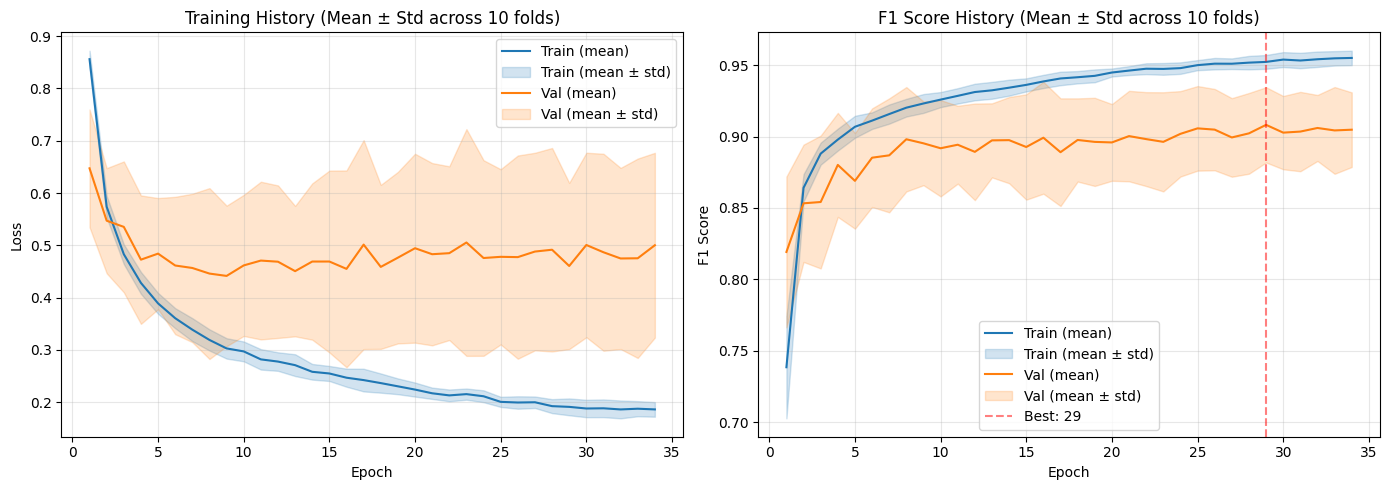

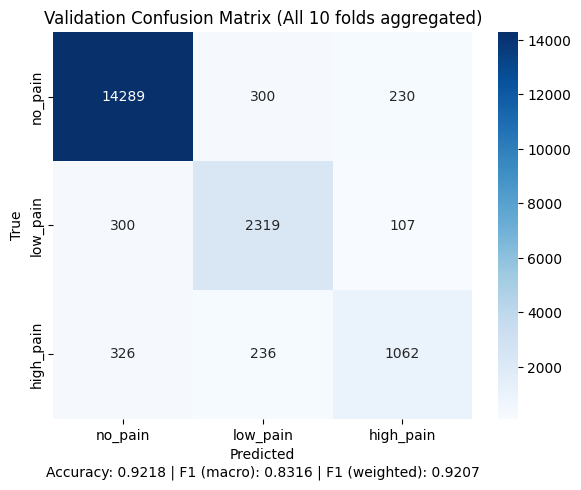


Aggregated metrics across all 10 folds:
Accuracy: 0.9218
F1 Score (macro): 0.8316
F1 Score (weighted): 0.9207


In [ ]:
# Aggregate training histories across all folds
num_epochs = min(len(h['val_f1']) for h in fold_histories)

# Aggregate only for epochs where all folds have data
agg_train_loss = []
agg_val_loss = []
agg_train_f1 = []
agg_val_f1 = []

for epoch in range(num_epochs):
    train_losses = [h['train_loss'][epoch] for h in fold_histories]
    val_losses = [h['val_loss'][epoch] for h in fold_histories]
    train_f1s = [h['train_f1'][epoch] for h in fold_histories]
    val_f1s = [h['val_f1'][epoch] for h in fold_histories]
    
    agg_train_loss.append((np.mean(train_losses), np.std(train_losses)))
    agg_val_loss.append((np.mean(val_losses), np.std(val_losses)))
    agg_train_f1.append((np.mean(train_f1s), np.std(train_f1s)))
    agg_val_f1.append((np.mean(val_f1s), np.std(val_f1s)))

# Find best epoch (highest mean val_f1)
best_epoch_idx = np.argmax([mean for mean, _ in agg_val_f1])
best_epoch = best_epoch_idx + 1
best_mean_val_f1, best_std_val_f1 = agg_val_f1[best_epoch_idx]
print(f"Best epoch: {best_epoch} (Mean Val F1: {best_mean_val_f1:.4f} ± {best_std_val_f1:.4f})")

# Plot training history with mean ± std
epochs = np.arange(1, num_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot with std bands
train_loss_mean = [mean for mean, _ in agg_train_loss]
train_loss_std = [std for _, std in agg_train_loss]
val_loss_mean = [mean for mean, _ in agg_val_loss]
val_loss_std = [std for _, std in agg_val_loss]

ax1.plot(epochs, train_loss_mean, label='Train (mean)', color='C0')
ax1.fill_between(epochs, 
                  np.array(train_loss_mean) - np.array(train_loss_std),
                  np.array(train_loss_mean) + np.array(train_loss_std),
                  alpha=0.2, color='C0', label='Train (mean ± std)')
ax1.plot(epochs, val_loss_mean, label='Val (mean)', color='C1')
ax1.fill_between(epochs,
                  np.array(val_loss_mean) - np.array(val_loss_std),
                  np.array(val_loss_mean) + np.array(val_loss_std),
                  alpha=0.2, color='C1', label='Val (mean ± std)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Training History (Mean ± Std across {N_SPLITS} folds)')

# F1 plot with std bands
train_f1_mean = [mean for mean, _ in agg_train_f1]
train_f1_std = [std for _, std in agg_train_f1]
val_f1_mean = [mean for mean, _ in agg_val_f1]
val_f1_std = [std for _, std in agg_val_f1]

ax2.plot(epochs, train_f1_mean, label='Train (mean)', color='C0')
ax2.fill_between(epochs,
                  np.array(train_f1_mean) - np.array(train_f1_std),
                  np.array(train_f1_mean) + np.array(train_f1_std),
                  alpha=0.2, color='C0', label='Train (mean ± std)')
ax2.plot(epochs, val_f1_mean, label='Val (mean)', color='C1')
ax2.fill_between(epochs,
                  np.array(val_f1_mean) - np.array(val_f1_std),
                  np.array(val_f1_mean) + np.array(val_f1_std),
                  alpha=0.2, color='C1', label='Val (mean ± std)')
ax2.axvline(best_epoch, color='r', linestyle='--', alpha=0.5, label=f'Best: {best_epoch}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 Score')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title(f'F1 Score History (Mean ± Std across {N_SPLITS} folds)')

plt.tight_layout()
plt.show()

# Collect predictions from all folds for confusion matrix
print("\nCollecting predictions from all folds...")
all_val_preds = []
all_val_targets = []

# Recreate fold splits to get validation data
df_train_for_cv = df_train.copy()
df_train_for_cv = df_train_for_cv.merge(df_labels, on='sample_index', how='left')
gkf = GroupKFold(n_splits=N_SPLITS)

fold_idx = 0
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(df_train_for_cv, df_train_for_cv["label_idx"], groups=df_train_for_cv["sample_index"])
):
    df_val_k = df_train_for_cv.iloc[val_idx].reset_index(drop=True)
    
    # Build sequences for validation set
    X_val_temporal_k, X_val_static_k, y_val_k = build_sequence(
        df_val_k, window_best, stride_best, temporal_feature_cols, static_feature_cols, df_labels
    )
    
    # Convert types
    X_val_temporal_k = X_val_temporal_k.astype(np.float32)
    X_val_static_k = X_val_static_k.astype(np.float32)
    y_val_k = y_val_k.astype(np.int64)
    
    # Create validation loader
    val_ds_k = TemporalStaticDataset(X_val_temporal_k, X_val_static_k, y_val_k)
    pin_memory = device.type == "cuda"
    val_loader_k = DataLoader(val_ds_k, batch_size=BATCH_SIZE_OPTUNA, shuffle=False, drop_last=False, num_workers=0, pin_memory=pin_memory)
    
    # Get model for this fold and make predictions
    fold_model = fold_models[fold]
    fold_model.eval()
    
    with torch.no_grad():
        for inputs_temporal, inputs_static, targets in val_loader_k:
            inputs_temporal = inputs_temporal.to(device)
            inputs_static = inputs_static.to(device)
            logits = fold_model(inputs_temporal, inputs_static)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_val_preds.append(preds)
            all_val_targets.append(targets.cpu().numpy())

# Aggregate all predictions
y_val_true = np.concatenate(all_val_targets)
y_val_pred = np.concatenate(all_val_preds)

# Create confusion matrix (using num_classes = 3)
num_classes = 3
cm = confusion_matrix(y_val_true, y_val_pred, labels=list(range(num_classes)))

# Get class names from label mapping if available, otherwise use default
try:
    class_names = [label for label, _ in sorted(label_mapping.items(), key=lambda item: item[1])]
except:
    class_names = ['no_pain', 'low_pain', 'high_pain']

fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('True')
ax_cm.set_title(f'Validation Confusion Matrix (All {N_SPLITS} folds aggregated)')

# Add accuracy/F1 info
from sklearn.metrics import f1_score, accuracy_score
acc = accuracy_score(y_val_true, y_val_pred)
f1_macro = f1_score(y_val_true, y_val_pred, average='macro')
f1_weighted = f1_score(y_val_true, y_val_pred, average='weighted')
ax_cm.text(0.5, -0.15, f'Accuracy: {acc:.4f} | F1 (macro): {f1_macro:.4f} | F1 (weighted): {f1_weighted:.4f}',
           transform=ax_cm.transAxes, ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nAggregated metrics across all {N_SPLITS} folds:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")


## 🏁 Evaluate and submit

In [ ]:
# Evaluate on test set using trained k-fold models
# Use same windowing approach as validation for consistency
print("--- Evaluating on Test Set with K-Fold Models ---")
print(f"Using window={window_best}, stride={stride_best} (same as training/validation)")

# Build test sequences using same parameters as training
X_test_temporal, X_test_static, test_sample_indices = build_sequence(
    df_public_test, window_best, stride_best, temporal_feature_cols, static_feature_cols, df_labels=None
)

# Convert types
X_test_temporal = X_test_temporal.astype(np.float32)
X_test_static = X_test_static.astype(np.float32)
test_sample_indices = np.array(test_sample_indices)

# Create dataset and loader (same as validation)
test_ds = TemporalStaticDataset(X_test_temporal, X_test_static, np.zeros(len(X_test_temporal)))  # Dummy labels
pin_memory = device.type == "cuda"
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_OPTUNA, shuffle=False, drop_last=False, num_workers=0, pin_memory=pin_memory)

# Collect predictions from all fold models
print(f"Making predictions with {len(fold_models)} fold models...")
all_fold_probs = []

for fold_idx, fold_model in enumerate(fold_models):
    fold_model.eval()
    fold_probs_list = []
    
    with torch.no_grad():
        for xb_temporal, xb_static, _ in test_loader:
            xb_temporal = xb_temporal.to(device)
            xb_static = xb_static.to(device)
            logits = fold_model(xb_temporal, xb_static)
            # Get probabilities for each window
            probs = torch.nn.functional.softmax(logits, dim=1)
            fold_probs_list.append(probs.cpu().numpy())
    
    # Concatenate all probabilities for this fold
    fold_probs = np.concatenate(fold_probs_list, axis=0) if fold_probs_list else np.empty((0, 3))
    all_fold_probs.append(fold_probs)
    print(f"  Fold {fold_idx+1}: {len(fold_probs)} windows processed")

# Stack probabilities from all folds: shape (n_folds, n_windows, n_classes)
all_fold_probs = np.stack(all_fold_probs, axis=0)  # Shape: (n_folds, n_windows, n_classes)

# Average probabilities across folds first, then across windows per sample
# First average across folds: shape (n_windows, n_classes)
avg_probs_across_folds = np.mean(all_fold_probs, axis=0)

# Create DataFrame with probabilities and sample indices
num_classes = 3
probs_df = pd.DataFrame(avg_probs_across_folds, columns=[0, 1, 2])
probs_df['sample_index'] = test_sample_indices

# Group by sample_index and take mean (aggregating windows per sample)
# This matches the validation approach - majority vote via averaged probabilities
probs_avg_per_sample = probs_df.groupby('sample_index')[[0, 1, 2]].mean()

# Get final predictions (majority vote = argmax of averaged probabilities)
final_predictions = []
for sample_id, probs_row in probs_avg_per_sample.iterrows():
    pred_class = probs_row.values.argmax()
    final_predictions.append((sample_id, pred_class))

print(f"\nProcessed {len(probs_avg_per_sample)} test samples")
print(f"Average windows per sample: {len(probs_df) / len(probs_avg_per_sample):.2f}")

# Map to labels and save
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

submission_df = pd.DataFrame({
    "sample_index": [f"{int(sid):03d}" for sid, _ in final_predictions],
    "label": [inverse_label_mapping[pred] for _, pred in final_predictions]
})

from datetime import datetime
submission_df.to_csv(datetime.now().strftime("%Y%m%d_%H%M%S_") + "submission.csv", index=False)
print(f"submission.csv created with {len(submission_df)} predictions")

--- Evaluating on Test Set with K-Fold Models ---
Using window=20, stride=5 (same as training/validation)
Making predictions with 10 fold models...
  Fold 1: 38396 windows processed
  Fold 2: 38396 windows processed
  Fold 3: 38396 windows processed
  Fold 4: 38396 windows processed
  Fold 5: 38396 windows processed
  Fold 6: 38396 windows processed
  Fold 7: 38396 windows processed
  Fold 8: 38396 windows processed
  Fold 9: 38396 windows processed
  Fold 10: 38396 windows processed

Processed 1324 test samples
Average windows per sample: 29.00
submission.csv created with 1324 predictions


### Check submission distribution (sanity check)

In [ ]:
print(submission_df['label'].value_counts())
print([i/sum(submission_df['label'].value_counts()) for i in submission_df['label'].value_counts()])

label
no_pain      1047
low_pain      187
high_pain      90
Name: count, dtype: int64
[0.790785498489426, 0.14123867069486404, 0.06797583081570997]
